the data set has the age and salaries of people who bought XUV . so we can use this to predict the customer buys an xuv or not and hence we can target the marketing towars them more

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
data = pd.read_csv('Social_Network_Ads.csv')

In [182]:
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [183]:
data.isnull().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    bool 
 1   EstimatedSalary  400 non-null    bool 
 2   Purchased        400 non-null    bool 
dtypes: bool(3)
memory usage: 1.3 KB


In [184]:
X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

In [185]:
print(X[:5])

[[   19 19000]
 [   35 20000]
 [   26 43000]
 [   27 57000]
 [   19 76000]]


In [186]:
from sklearn.model_selection import train_test_split

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

we need to scale age and salary , the output value of buy or not buy is already 0/1 , so we don't need to scale it

In [188]:
print(X_train[:5])

[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]]


In [189]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [190]:
print(X_train[:5])

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]


In [191]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)

In [192]:
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [193]:
predictions = lr.predict(X_test)
print(predictions)
lr.predict(sc.transform([[30,87000]]))

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 1 1 1]


array([0])

hence we can conclude that they will not purchase the XUV

In [194]:
print(np.concatenate((predictions.reshape(len(predictions),1),y_test.reshape(len(y_test),1)),1)[:10])

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]]


In [195]:
d = np.concatenate((predictions.reshape(len(predictions),1),y_test.reshape(len(y_test),1)),1)
pd.DataFrame(d , columns = ['Predicted values ','actual values as in test set']).head()

,Predicted values,actual values as in test set
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [196]:
print(sc.inverse_transform(X_test).astype(int)[:5])

[[   30 87000]
 [   38 50000]
 [   35 75000]
 [   30 79000]
 [   35 50000]]


In [197]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [198]:
cm = confusion_matrix(y_test,predictions)
accuracy_score(y_test,predictions)

0.91

In [199]:
print(cm)

[[65  3]
 [ 6 26]]


In [200]:
from sklearn.metrics import classification_report 
classification_report(y_test,predictions)

'              precision    recall  f1-score   support\n\n           0       0.92      0.96      0.94        68\n           1       0.90      0.81      0.85        32\n\n    accuracy                           0.91       100\n   macro avg       0.91      0.88      0.89       100\nweighted avg       0.91      0.91      0.91       100\n'

In [99]:
#sns.pairplot(data)

to visualize the output

C:\Users\Public.PayOk\AppData\Local\Temp\ipykernel_17712\4020064575.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(['#FA8072', '#1E90FF'])(i), label = j)


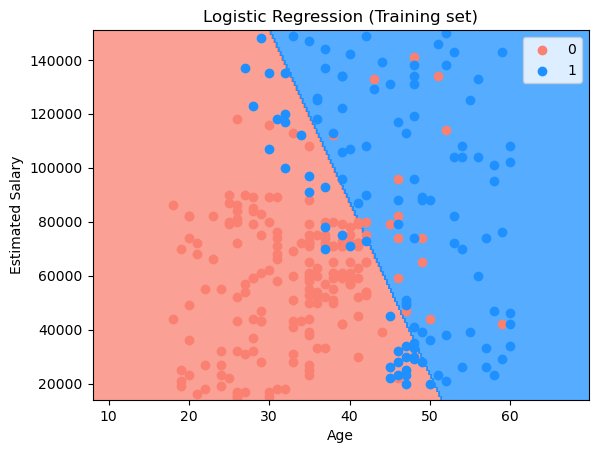

In [203]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(['#FA8072', '#1E90FF'])(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()

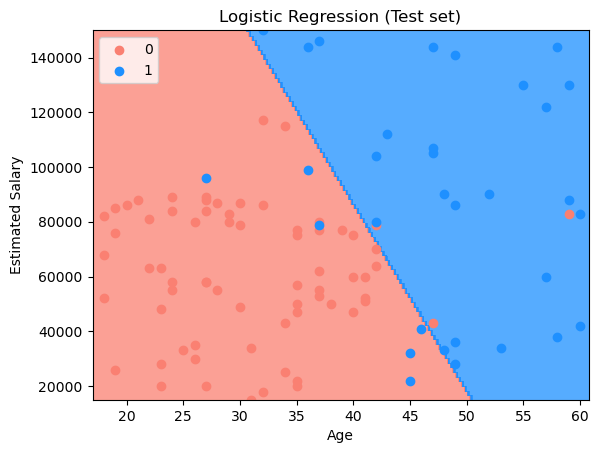

In [206]:

X_set, y_set = sc.inverse_transform(X_test), y_test
# Create a grid of points
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.25),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.25)
)
# Predict for each point on the grid
Z = lr.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape)
# Plot the decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']) )
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
# Define colors for scatter plot
colors = ['#FA8072', '#1E90FF']
# Plot the test set points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        color=colors[i], label=j
    )
# Add titles and labels
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()